# Adaptive Nonlinear Vector Autoregression: Robust Forecasting for Noisy Chaotic Time Series
## Author
- **Name**: Azimov Sherkhon Azizkhon Ugli
- **Email**: sherxonazimov94@pusan.ac.kr
- **GitHub**: @AzimovSherkhon

Method: **Adaptive Nonlinear Vector Autoregression** 

Code: Grid Search \
k_grid = [2, 10, 30, 50] \
hidden_dim_grid = [10, 20, 50, 100, 200, 500, 1000] \
adam_lr_grid = [1e-4, 1e-3, 1e-2] \
lbfgs_lr_grid = [1.0, 0.5, 0.1]

In [1]:
# ============================================================
# Imports & Setup
# ============================================================
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# Torch defaults
torch.set_default_dtype(torch.float32)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")
if device.type == "cuda":
    print(f"CUDA device: {torch.cuda.current_device()} - {torch.cuda.get_device_name(0)}")

# Suppress unnecessary warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Device in use: cuda
CUDA device: 0 - A100-PCIE-40GB


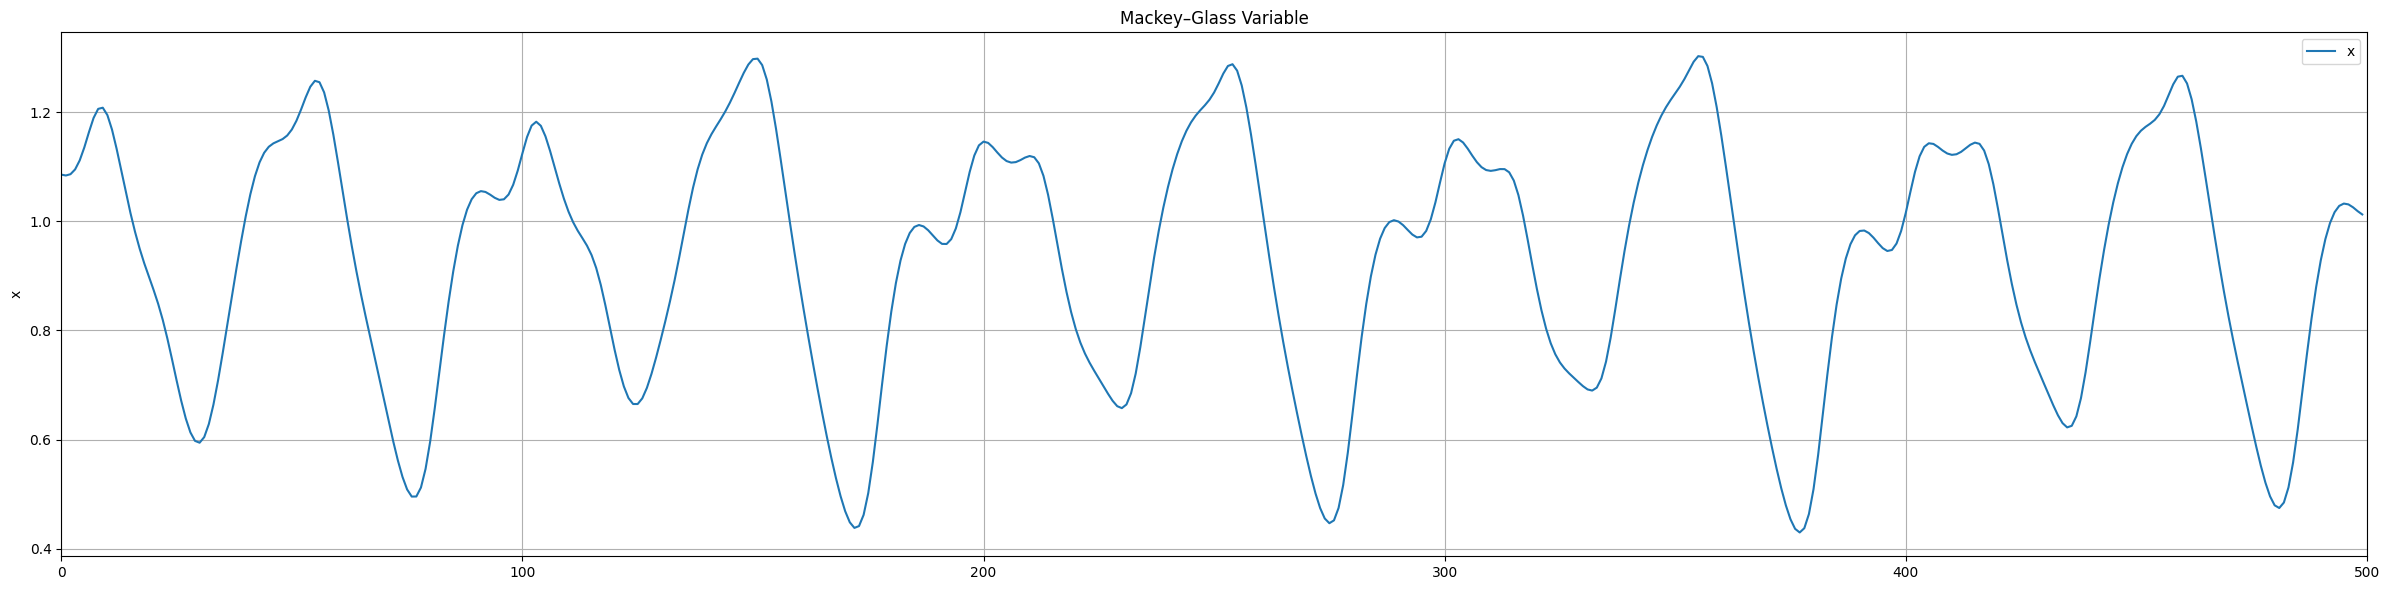

In [2]:
# ============================================================
# Load Mackey–Glass Data
# ============================================================
mg_data = np.load("ground_truth.npy")   # shape: [d, T]
mg = mg_data.T


# ============================================================
# Visualization
# ============================================================
plt.figure(figsize=(24, 6))
plt.plot(mg_data[0, 500:1000], label="x", color="C0")
plt.title("Mackey–Glass Variable")
plt.ylabel("x")
plt.grid(True)
plt.legend()
plt.xlim(0, 500)
plt.tight_layout()
plt.show()

In [3]:
# ============================================================
# Reproducibility
# ============================================================
seed = 2025
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# Dataset Preparation
# ============================================================
def add_relative_gaussian_noise(X_clean, noise_scale):
    """Adds relative Gaussian noise to a dataset."""
    signal_std = np.std(X_clean, axis=0)
    noise = np.random.normal(0.0, noise_scale * signal_std, X_clean.shape)
    return X_clean + noise


# Measurement noise (applied globally to dataset)
dataset_noise_scale = 0.30  # Moderate noise case
X_noisy_dataset = add_relative_gaussian_noise(mg, dataset_noise_scale)

X = torch.tensor(X_noisy_dataset, dtype=torch.float32)  # noisy input
X_true = torch.tensor(mg, dtype=torch.float32)          # clean reference

# Dataset splits
warmup_len, train_len, val_len, test_len = 500, 7500, 1000, 1000

X_warmup = X[:warmup_len].to(device)
X_train_clean = X[warmup_len:warmup_len + train_len]
X_val  = X[warmup_len + train_len : warmup_len + train_len + val_len].to(device)
X_test = X[warmup_len + train_len + val_len : warmup_len + train_len + val_len + test_len].to(device)

# Ground truth references
X_val_true  = X_true[warmup_len + train_len : warmup_len + train_len + val_len].to(device)
X_test_true = X_true[warmup_len + train_len + val_len : warmup_len + train_len + val_len + test_len].to(device)

# Training-time noise (works as a regularization only during training)
train_noise_scale = 0.0  # We only add it for noise free-case
signal_std = X_train_clean.std(dim=0, keepdim=True).cpu().numpy()
train_noise = np.random.normal(0.0, train_noise_scale * signal_std, X_train_clean.shape)
X_train = torch.tensor((X_train_clean.cpu().numpy() + train_noise).astype(np.float32), device=device)

In [4]:
# ============================================================
# Adaptive NVAR Model
# ============================================================
class FeatureMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


class AdaptiveNVARModel(nn.Module):
    def __init__(self, dk, m, d, hidden_dim):
        super().__init__()
        self.mlp = FeatureMLP(dk, hidden_dim, m)
        self.readout = nn.Linear(dk + m, d, bias=False)

    def forward(self, H_lin):
        H_nn = self.mlp(H_lin)
        H_total = torch.cat([H_lin, H_nn], dim=1)
        return self.readout(H_total)


# ============================================================
# Helper Functions
# ============================================================
def construct_H_lin(X, k):
    """Constructs delay-embedded features from time series."""
    T = X.shape[0]
    return torch.cat([X[i:T - k + i] for i in range(k)], dim=1)


def init_weights_stable(m):
    """Stable Xavier initialization for linear layers."""
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)


# ============================================================
# Training Function (Adam + L-BFGS)
# ============================================================
def train_joint_model_with_lbfgs(
    X, k, m, hidden_dim=200,
    lr_adam=1e-4, lr_lbfgs=1.0,
    max_epochs_adam=5000, num_epochs_lbfgs=1000,
    save_path="best_joint_model.pth",
    adam_patience=200, tolerance=1e-20,
    device=None
):
    """Train Adaptive NVAR model using Adam + L-BFGS optimization."""
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X = X.to(device)

    # Prepare features & targets
    H_lin = construct_H_lin(X, k)       # [n, dk]
    Y = X[k:] - X[k-1:-1]               # [n, d]
    n, dk = H_lin.shape
    d = Y.shape[1]

    # Initialize model
    model = AdaptiveNVARModel(dk, m, d, hidden_dim).to(device)
    model.apply(init_weights_stable)

    # --- Phase 1: Adam ---
    optimizer = torch.optim.Adam(model.parameters(), lr=lr_adam)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=50)

    best_loss = float("inf")
    epochs_no_improve = 0

    for epoch in range(max_epochs_adam):
        model.train()
        Y_hat = model(H_lin)
        loss = F.mse_loss(Y_hat, Y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step(loss.item())

        if best_loss - loss.item() > tolerance:
            best_loss, epochs_no_improve = loss.item(), 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= adam_patience:
            break

    torch.save(model.state_dict(), save_path)

    # --- Phase 2: L-BFGS ---
    model.load_state_dict(torch.load(save_path))
    optimizer = torch.optim.LBFGS(
        model.parameters(),
        lr=lr_lbfgs,
        max_iter=50,
        tolerance_grad=1e-10,
        tolerance_change=1e-10,
        history_size=50,
        line_search_fn="strong_wolfe"
    )

    best_loss, epochs_no_improve = float("inf"), 0

    def closure():
        optimizer.zero_grad()
        Y_hat = model(H_lin)
        loss = F.mse_loss(Y_hat, Y)
        loss.backward()
        return loss

    for epoch in range(num_epochs_lbfgs):
        model.train()
        loss = optimizer.step(closure)
        current_loss = loss.item()

        if best_loss - current_loss > tolerance:
            best_loss, epochs_no_improve = current_loss, 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= 200:
            break

    torch.save(model.state_dict(), save_path)
    return model

In [5]:
# ============================================================
# Grid Search
# ============================================================
k_grid = [2, 10, 30, 50]
hidden_dim_grid = [10, 20, 50, 100, 200, 500, 1000]
adam_lr_grid = [1e-4, 1e-3, 1e-2]
lbfgs_lr_grid = [1.0, 0.5, 0.1]
horizons = [25, 50, 75, 100]

base_seed, num_runs, num_windows = 2025, 5, 10
d = 1
best_config, best_rmse, all_results = None, float("inf"), []

print("Starting Grid Search...\n")

for k in k_grid:
    dk = d * k
    m = int((dk * (dk + 1)) / 2)

    for hidden_dim in hidden_dim_grid:
        for lr_adam in adam_lr_grid:
            for lr_lbfgs in lbfgs_lr_grid:

                all_run_rmses = {h: [] for h in horizons}

                for run in range(num_runs):
                    seed = base_seed + run
                    torch.manual_seed(seed)
                    torch.cuda.manual_seed_all(seed)
                    torch.backends.cudnn.deterministic = True
                    torch.backends.cudnn.benchmark = False

                    model_path = f"model_noise{dataset_noise_scale}_k{k}_hd{hidden_dim}_adam{lr_adam}_lbfgs{lr_lbfgs}.pth"

                    model = train_joint_model_with_lbfgs(
                        X_train, k, m, hidden_dim,
                        lr_adam, lr_lbfgs,
                        save_path=model_path
                    )
                    model.eval()

                    window_size = len(X_val_true) // num_windows
                    horizon_rmses = {h: [] for h in horizons}

                    for w in range(num_windows):
                        start, end = w * window_size, (w + 1) * window_size
                        X_val_true_window = X_val_true[start:end]

                        init_start = warmup_len + train_len + start - k
                        init_end   = warmup_len + train_len + start
                        X_init = X[init_start:init_end].to(device)

                        x_t = [x.clone() for x in X_init.unbind(0)]
                        H_lin = torch.cat(x_t, dim=-1).unsqueeze(0)

                        predictions = []
                        for _ in range(window_size):
                            with torch.no_grad():
                                delta_x = model(H_lin)
                            x_next = x_t[-1] + delta_x.squeeze(0)
                            predictions.append(x_next)
                            x_t = x_t[1:] + [x_next]
                            H_lin = torch.cat(x_t, dim=-1).unsqueeze(0)

                        predictions_np = torch.stack(predictions).cpu().numpy()
                        y_true_np = X_val_true_window.cpu().numpy()

                        for h in horizons:
                            if h <= window_size:
                                rmse = np.sqrt(np.mean((y_true_np[:h] - predictions_np[:h]) ** 2))
                                horizon_rmses[h].append(rmse)

                    for h in horizons:
                        avg_rmse = np.mean(horizon_rmses[h])
                        all_run_rmses[h].append(avg_rmse)

                avg_rmse_horizons = {h: np.mean(all_run_rmses[h]) for h in horizons}
                print(f"[Grid Search] k={k}, hd={hidden_dim}, Adam LR={lr_adam}, L-BFGS LR={lr_lbfgs} → " +
                      ", ".join([f"h={h}: {avg_rmse_horizons[h]:.6f}" for h in horizons]))

                all_results.append((k, hidden_dim, lr_adam, lr_lbfgs, avg_rmse_horizons))

                if avg_rmse_horizons[100] < best_rmse:
                    best_rmse = avg_rmse_horizons[100]
                    best_config = (k, hidden_dim, lr_adam, lr_lbfgs, num_runs, num_windows, window_size)

print("\n✅ Best Config Found:")
print(f"k={best_config[0]}, hidden_dim={best_config[1]}, Adam LR={best_config[2]}, L-BFGS LR={best_config[3]}")
print(f"Best RMSE@100 = {best_rmse:.6f}")
print(f"Runs: {best_config[4]}, Windows: {best_config[5]}, Window Size: {best_config[6]}")
print(f"Horizons evaluated: {horizons}")

Starting Grid Search...

[Grid Search] k=2, hd=10, Adam LR=0.0001, L-BFGS LR=1.0 → h=25: 0.185793, h=50: 0.196697, h=75: 0.201826, h=100: 0.221791
[Grid Search] k=2, hd=10, Adam LR=0.0001, L-BFGS LR=0.5 → h=25: 0.187232, h=50: 0.197952, h=75: 0.202476, h=100: 0.222139
[Grid Search] k=2, hd=10, Adam LR=0.0001, L-BFGS LR=0.1 → h=25: 0.315147, h=50: 0.400222, h=75: 0.417966, h=100: 0.447717
[Grid Search] k=2, hd=10, Adam LR=0.001, L-BFGS LR=1.0 → h=25: 0.189892, h=50: 0.193734, h=75: 0.200817, h=100: 0.218634
[Grid Search] k=2, hd=10, Adam LR=0.001, L-BFGS LR=0.5 → h=25: 0.188570, h=50: 0.194774, h=75: 0.200577, h=100: 0.218903
[Grid Search] k=2, hd=10, Adam LR=0.001, L-BFGS LR=0.1 → h=25: 0.188695, h=50: 0.194855, h=75: 0.200624, h=100: 0.218921
[Grid Search] k=2, hd=10, Adam LR=0.01, L-BFGS LR=1.0 → h=25: 0.185830, h=50: 0.192578, h=75: 0.198517, h=100: 0.217307
[Grid Search] k=2, hd=10, Adam LR=0.01, L-BFGS LR=0.5 → h=25: 0.185854, h=50: 0.191900, h=75: 0.198616, h=100: 0.217242
[Grid 

In [6]:
# ============================================================
# Reload Best Model (after grid search)
# ============================================================
best_k, best_hidden, best_lr_adam, best_lr_lbfgs, _, num_windows, window_size = best_config
best_dk = d * best_k
best_m = (best_dk * (best_dk + 1)) // 2

best_model_path = f"model_noise{dataset_noise_scale}_k{best_k}_hd{best_hidden}_adam{best_lr_adam}_lbfgs{best_lr_lbfgs}.pth"
best_model = AdaptiveNVARModel(dk=best_dk, m=best_m, d=d, hidden_dim=best_hidden).to(device)
best_model.load_state_dict(torch.load(best_model_path, map_location=device))
best_model.eval()


# ============================================================
# Rollout Validation Predictions
# ============================================================
all_preds, all_true, all_noisy = [], [], []

for w in range(num_windows):
    start, end = w * window_size, (w + 1) * window_size

    X_val_true_window = X_val_true[start:end]
    X_val_noisy_window = X_val[start:end]

    # Initialize with noisy context window
    init_start = warmup_len + train_len + start - best_k
    init_end   = warmup_len + train_len + start
    X_init = X[init_start:init_end].to(device)

    x_t = [x.clone() for x in X_init.unbind(0)]
    H_lin = torch.cat(x_t, dim=-1).unsqueeze(0)

    # Autoregressive rollout
    predictions = []
    for _ in range(window_size):
        with torch.no_grad():
            delta_x = best_model(H_lin)
        x_next = x_t[-1] + delta_x.squeeze(0)
        predictions.append(x_next)

        # Update state
        x_t = x_t[1:] + [x_next]
        H_lin = torch.cat(x_t, dim=-1).unsqueeze(0)

    all_preds.append(torch.stack(predictions).cpu().numpy())
    all_true.append(X_val_true_window.cpu().numpy())
    all_noisy.append(X_val_noisy_window.cpu().numpy())

# Concatenate windows
y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_true)
y_noisy = np.concatenate(all_noisy)


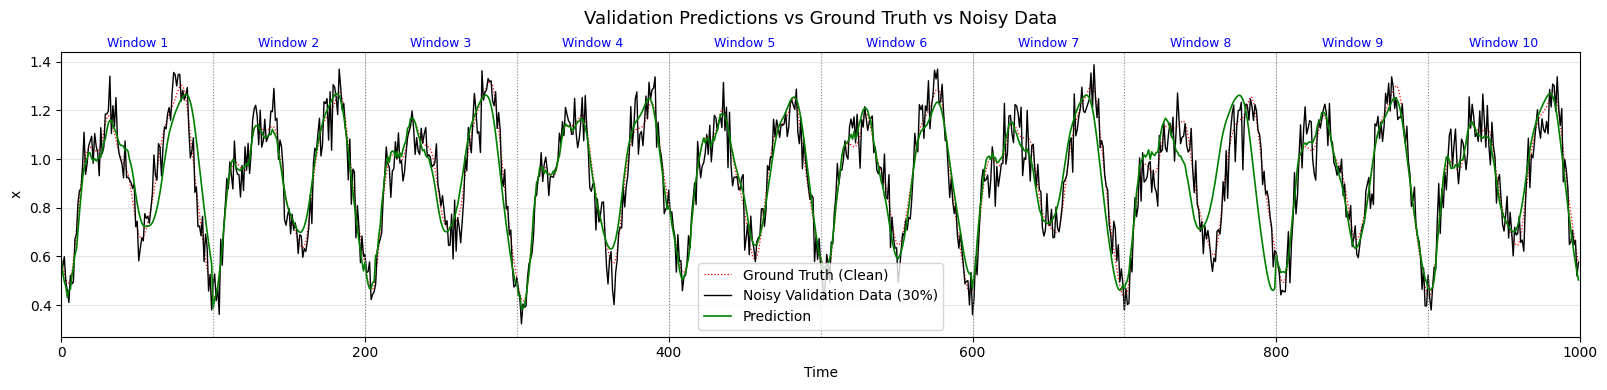

Saved plot as: validation_pred_vs_truth_k50_hd10_noise0.30.png


In [8]:
# ============================================================
# Visualization
# ============================================================
plt.figure(figsize=(16, 4))
plt.plot(y_true,  label="Ground Truth (Clean)", color="red", linestyle=":", linewidth=0.9)
plt.plot(y_noisy, label=f"Noisy Validation Data ({dataset_noise_scale*100:.0f}%)", 
         color="black", linewidth=1.0, alpha=1.0)
plt.plot(y_pred,  label="Prediction", color="green", linewidth=1.2)

# Mark window boundaries
for w in range(1, num_windows):
    plt.axvline(w * window_size, color="gray", linestyle="dotted", linewidth=0.8)
# Label windows at the center
for w in range(num_windows):
    center = w * window_size + window_size // 2
    plt.text(center, max(y_true)*1.10, f"Window {w+1}", ha="center", va="bottom", fontsize=9, color="blue")
    
plt.title("Validation Predictions vs Ground Truth vs Noisy Data", fontsize=13, pad=20)
plt.xlabel("Time")
plt.ylabel("x")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.xlim(0, 1000)
filename = f"validation_pred_vs_truth_k{best_k}_hd{best_hidden}_noise{dataset_noise_scale:.2f}.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved plot as: {filename}")